# 1 individuali uzduotis

Autorius: Augustas Kniška
LSP: 2312054
Variantas: ResNet50; klases: Bee, Castle, Train
Uzdoties versija: 2026-02-22

In [2]:
import os

from openimages.download import download_dataset

In [3]:
data_dir = 'data'
number_of_images = 1000
classes = ['Train', 'Bee', 'Castle']

In [4]:
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

In [ ]:
# Download the dataset
# download_dataset(data_dir, classes, limit=number_of_images)

In [5]:

import torch
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.models import resnet50, ResNet50_Weights
import numpy as np
from PIL import Image
import glob
import matplotlib.pyplot as plt

In [6]:

train_indices = [466, 565, 820, 547, 811]
bee_indices = [309]
castle_indices = [483] 

def get_class_probability(model_output, indices):
    probs = torch.nn.functional.softmax(model_output, dim=1)
    class_prob = probs[:, indices].sum(dim=1)
    return class_prob

In [7]:
class ImageFolderDataset(Dataset):
    def __init__(self, root_dir, classes, transform=None, cache=False):
        self.root_dir = root_dir
        self.classes = classes
        self.transform = transform
        self.cache = cache
        self._cache = {}
        self.samples = []

        for class_idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(self.root_dir, class_name.lower(), "images")
            if not os.path.isdir(class_dir):
                continue
            files = glob.glob(os.path.join(class_dir, "*.jpg"))
            for file_path in files:
                self.samples.append((file_path, class_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        if self.cache and file_path in self._cache:
            image = self._cache[file_path]
        else:
            image = Image.open(file_path).convert("RGB")
            if self.transform:
                image = self.transform(image)
            else:
                image = transforms.ToTensor()(image)
            if self.cache:
                self._cache[file_path] = image
        return image, label

## Duomenu nuskaitymas ir nasumas

- `ImageFolderDataset` surenka failus is kiekvienos klases aplanko ir priskiria sveika skaiciu zyme (0/1/2).
- `cache=True` leidzia laikyti apdorotus tenzorius atmintyje, kad pakartotiniai nuskaitymai butu greitesni (1000 vaizdu atveju tai saugu).
- `DataLoader` su `num_workers` valdo nuskaitymo paralelizavima. Windows sistemoje saugiausia pradeti nuo 0 ir didinti tik jei reikia.
- Transformacijos atliekamos `weights.transforms()` pipeline, kuris atlieka resize, normalizavima ir kitus modelio reikalaujamus veiksmus.

In [8]:
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)
model.eval()

preprocess = weights.transforms()
dataset = ImageFolderDataset(data_dir, classes, transform=preprocess, cache=True)


num_workers = 0
pin_memory = torch.cuda.is_available()

loader_kwargs = dict(
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=(num_workers > 0),
)
if num_workers > 0:
    loader_kwargs["prefetch_factor"] = 2

dataloader = DataLoader(dataset, **loader_kwargs)

len(dataset)

2246

In [9]:
print(dataset[0][0].shape, dataset[0][1])

torch.Size([3, 224, 224]) 0


In [10]:
iterator = iter(dataloader)

In [11]:
images, labels = next(iterator)

2026-02-23  13:44:23 WARNING Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].


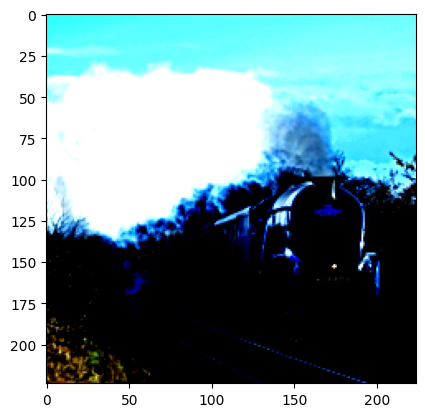

In [12]:
plt.imshow(images[0].permute(1, 2, 0))

In [13]:
batch = images[0].unsqueeze(0)
batch.shape

torch.Size([1, 3, 224, 224])

In [14]:
with torch.no_grad():
    outputs = model(batch)

class_probs = [
    get_class_probability(outputs, train_indices),
    get_class_probability(outputs, bee_indices),
    get_class_probability(outputs, castle_indices),
]
class_probs

[tensor([0.3900]), tensor([0.0006]), tensor([0.0007])]

In [15]:
for name, prob in zip(classes, class_probs):
    print(f"{name}: {prob.item():.4f}")

Train: 0.3900
Bee: 0.0006
Castle: 0.0007


In [16]:
print("Class probabilities:")
for name, prob in zip(classes, class_probs):
    print(f"  {name}: {prob.item():.4f}")

true_class = classes[int(labels[0])]
print(f"\nTrue class: {true_class}")

Class probabilities:
  Train: 0.3900
  Bee: 0.0006
  Castle: 0.0007

True class: Train


## Metrikos ir slenkstis

Toliau skaiciuojame tiksluma, precizija, atkurima ir F1 kiekvienai klasei kaip binarinei uzduociai (viena klase pries visas kitas). Slenkstis `threshold` keicia sprendimo riba, o metrikos perskaiciuojamos is naujo.

In [19]:
threshold = 0.7

def compute_metrics(y_true, y_probs, threshold):
    y_pred = (y_probs >= threshold).astype(int)
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tn = np.sum((y_true == 0) & (y_pred == 0))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0
    return accuracy, precision, recall, f1

all_true = {0: [], 1: [], 2: []}
all_probs = {0: [], 1: [], 2: []}

model.eval()
with torch.no_grad():
    for images, labels in dataloader:
        outputs = model(images)
        prob_train = get_class_probability(outputs, train_indices)
        prob_bee = get_class_probability(outputs, bee_indices)
        prob_castle = get_class_probability(outputs, castle_indices)
        probs = [prob_train, prob_bee, prob_castle]

        for class_idx, prob in enumerate(probs):
            all_probs[class_idx].extend(prob.cpu().numpy())
            all_true[class_idx].extend((labels == class_idx).cpu().numpy().astype(int))

for class_idx, class_name in enumerate(classes):
    y_true = np.array(all_true[class_idx])
    y_probs = np.array(all_probs[class_idx])
    accuracy, precision, recall, f1 = compute_metrics(y_true, y_probs, threshold)
    print(f"{class_name} -> Acc: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}")

Train -> Acc: 0.557, Precision: 1.000, Recall: 0.006, F1: 0.012
Bee -> Acc: 0.561, Precision: 1.000, Recall: 0.003, F1: 0.006
Castle -> Acc: 0.886, Precision: 1.000, Recall: 0.008, F1: 0.015


## Slenkscio itaka metrikoms

Zemiau pavaizduojame, kaip tikslumas, precizija, atkurimas ir F1 kinta priklausomai nuo slenkscio. Grafikai skaiciuojami is tu paciu `all_true` ir `all_probs` masyvu.

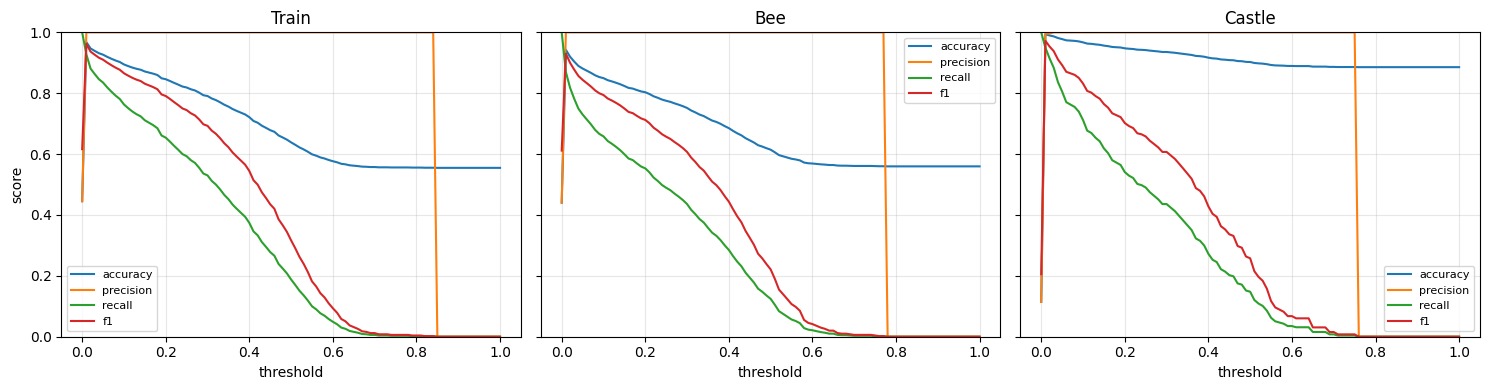

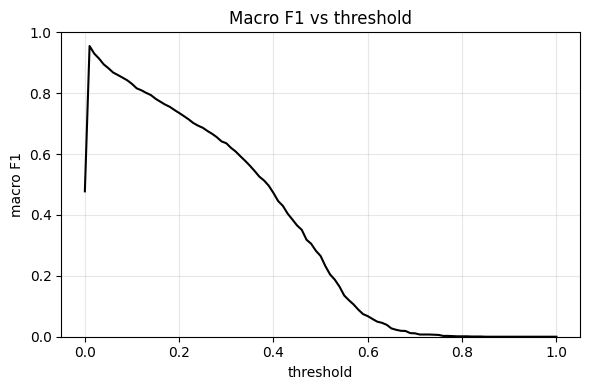

In [20]:
thresholds = np.linspace(0.0, 1.0, 101)
metric_names = ["accuracy", "precision", "recall", "f1"]

per_class_metrics = {class_idx: {name: [] for name in metric_names} for class_idx in range(len(classes))}

for t in thresholds:
    for class_idx in range(len(classes)):
        y_true = np.array(all_true[class_idx])
        y_probs = np.array(all_probs[class_idx])
        accuracy, precision, recall, f1 = compute_metrics(y_true, y_probs, t)
        per_class_metrics[class_idx]["accuracy"].append(accuracy)
        per_class_metrics[class_idx]["precision"].append(precision)
        per_class_metrics[class_idx]["recall"].append(recall)
        per_class_metrics[class_idx]["f1"].append(f1)

fig, axes = plt.subplots(1, len(classes), figsize=(15, 4), sharey=True)
for class_idx, class_name in enumerate(classes):
    ax = axes[class_idx]
    for name in metric_names:
        ax.plot(thresholds, per_class_metrics[class_idx][name], label=name)
    ax.set_title(class_name)
    ax.set_xlabel("threshold")
    if class_idx == 0:
        ax.set_ylabel("score")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.0, 1.0)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

macro_f1 = np.mean([per_class_metrics[i]["f1"] for i in range(len(classes))], axis=0)
plt.figure(figsize=(6, 4))
plt.plot(thresholds, macro_f1, color="black")
plt.title("Macro F1 vs threshold")
plt.xlabel("threshold")
plt.ylabel("macro F1")
plt.grid(True, alpha=0.3)
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()